# Decision Trees and Random Forest

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree, export_text

In [8]:
# 1. Load the data
df = pd.read_csv('data_cleaned.csv')

# 2. Preprocessing
# Explicitly drop 'Metro station' as requested by the user
df = df.drop('Metro station', axis=1)

# Identify categorical features and use one-hot encoding
categorical_cols = ['Apartment type', 'Region', 'Renovation'] # 'Metro station' removed
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features (X) and target variable (y)
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

# 3. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 1: Initial Decision Tree Regression

Initial Decision Tree:
R-squared: 0.5763
RMSE:      60404260.45



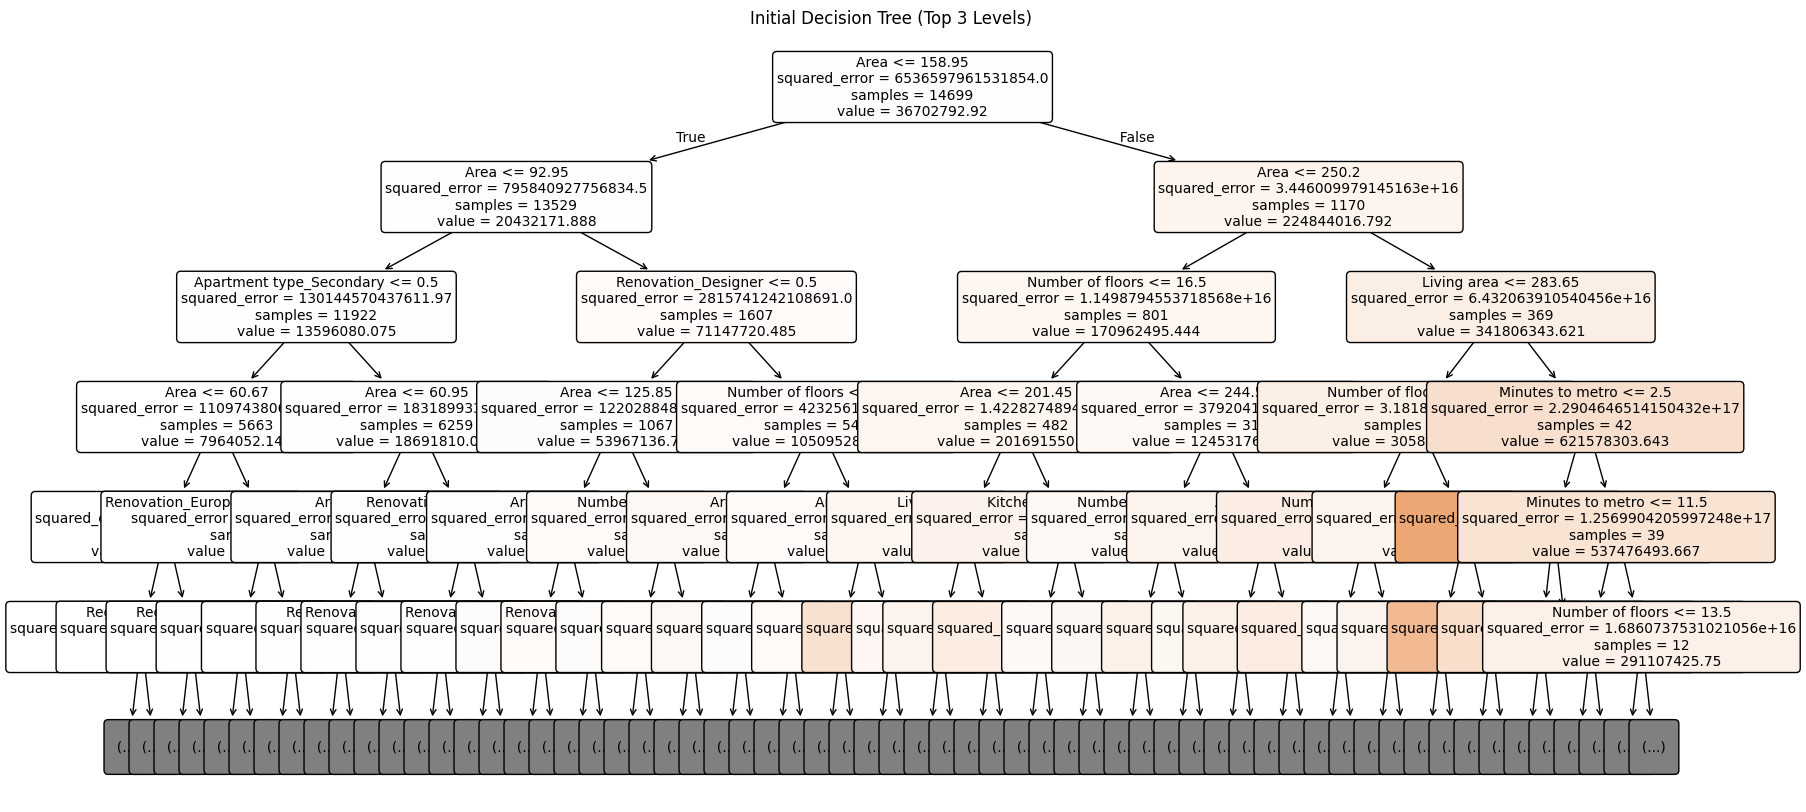

In [9]:
dt_initial = DecisionTreeRegressor(random_state=42)
dt_initial.fit(X_train, y_train)

# Predictions and metrics
dt_initial_preds = dt_initial.predict(X_test)
dt_initial_r2 = r2_score(y_test, dt_initial_preds)
dt_initial_rmse = np.sqrt(mean_squared_error(y_test, dt_initial_preds))

print("Initial Decision Tree:")
print(f"R-squared: {dt_initial_r2:.4f}")
print(f"RMSE:      {dt_initial_rmse:.2f}\n")

# Visualize the Initial Decision Tree
# max_depth=5 to see the top-level splits and reduce computation time
plt.figure(figsize=(20, 10))
plot_tree(dt_initial,
          feature_names=X_train.columns.tolist(),
          filled=True,
          rounded=True,
          max_depth=5,
          fontsize=10)
plt.title("Initial Decision Tree (Top 3 Levels)")
plt.show()

# Step 2: Optimization of the Decision Tree

=== Optimized Decision Tree ===
Best Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 20}
R-squared:   0.6135
RMSE:        57694259.85



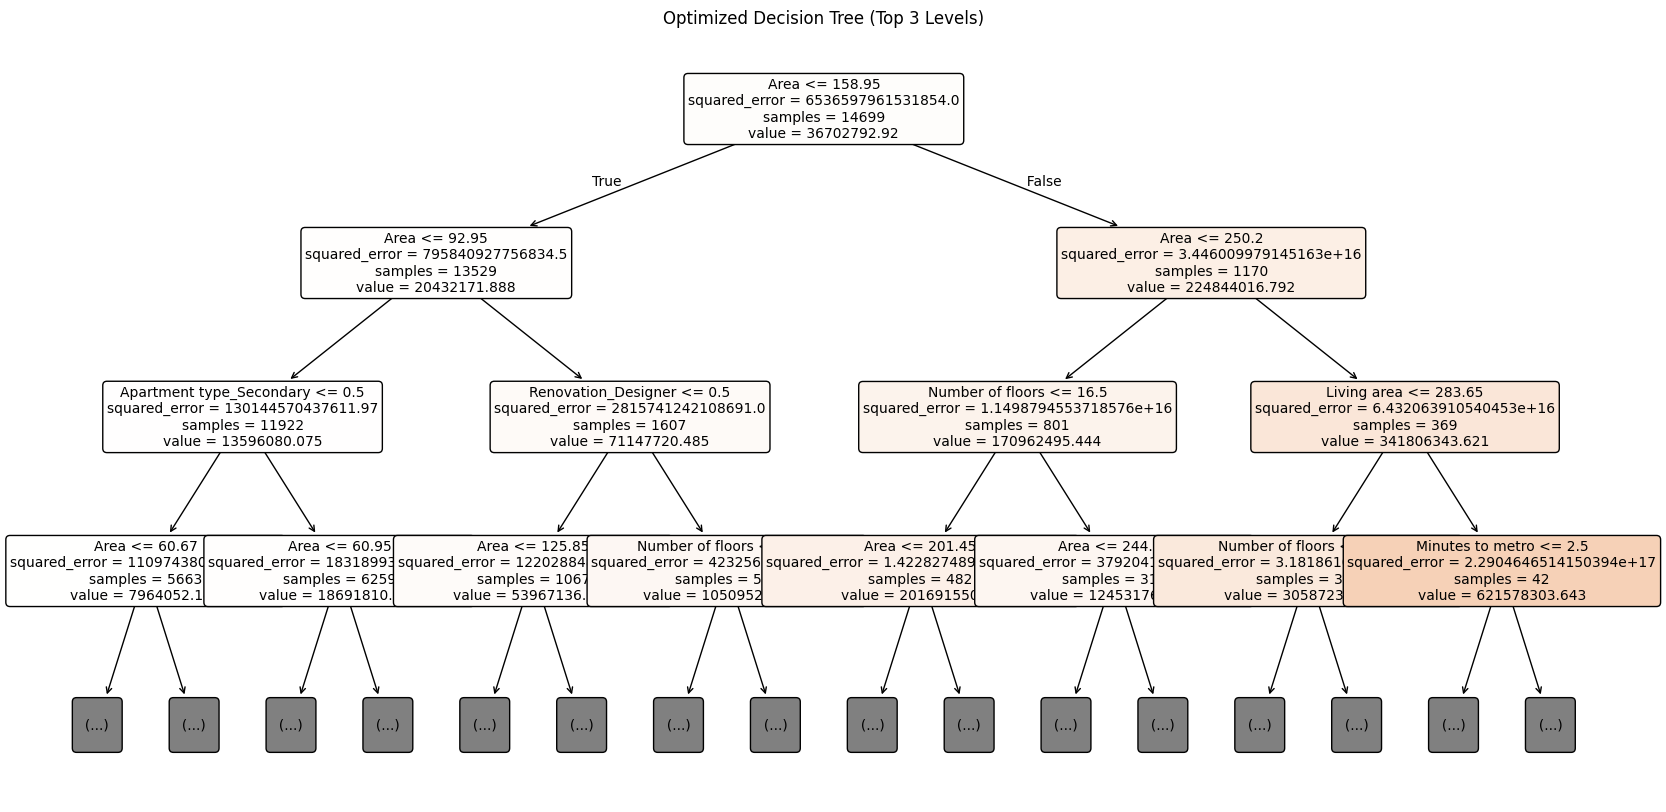

In [10]:
# Using GridSearchCV to find optimal hyperparameters
dt_param_grid = {
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# Cross-validation setup (5-fold)
grid_search_dt = GridSearchCV(estimator=DecisionTreeRegressor(random_state=42),
                              param_grid=dt_param_grid,
                              cv=5,
                              scoring='neg_mean_squared_error',
                              n_jobs=-1)

grid_search_dt.fit(X_train, y_train)
dt_optimized = grid_search_dt.best_estimator_

# Predictions and metrics
dt_opt_preds = dt_optimized.predict(X_test)
dt_opt_r2 = r2_score(y_test, dt_opt_preds)
dt_opt_rmse = np.sqrt(mean_squared_error(y_test, dt_opt_preds))

print("=== Optimized Decision Tree ===")
print(f"Best Params: {grid_search_dt.best_params_}")
print(f"R-squared:   {dt_opt_r2:.4f}")
print(f"RMSE:        {dt_opt_rmse:.2f}\n")

# Visualize the Optimized Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt_optimized,
          feature_names=X_train.columns.tolist(),
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title("Optimized Decision Tree (Top 3 Levels)")
plt.show()

# Step 3: Random Forest Regression

Optimized Random Forest:
Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}
R-squared:   0.6922
RMSE:        51486117.13



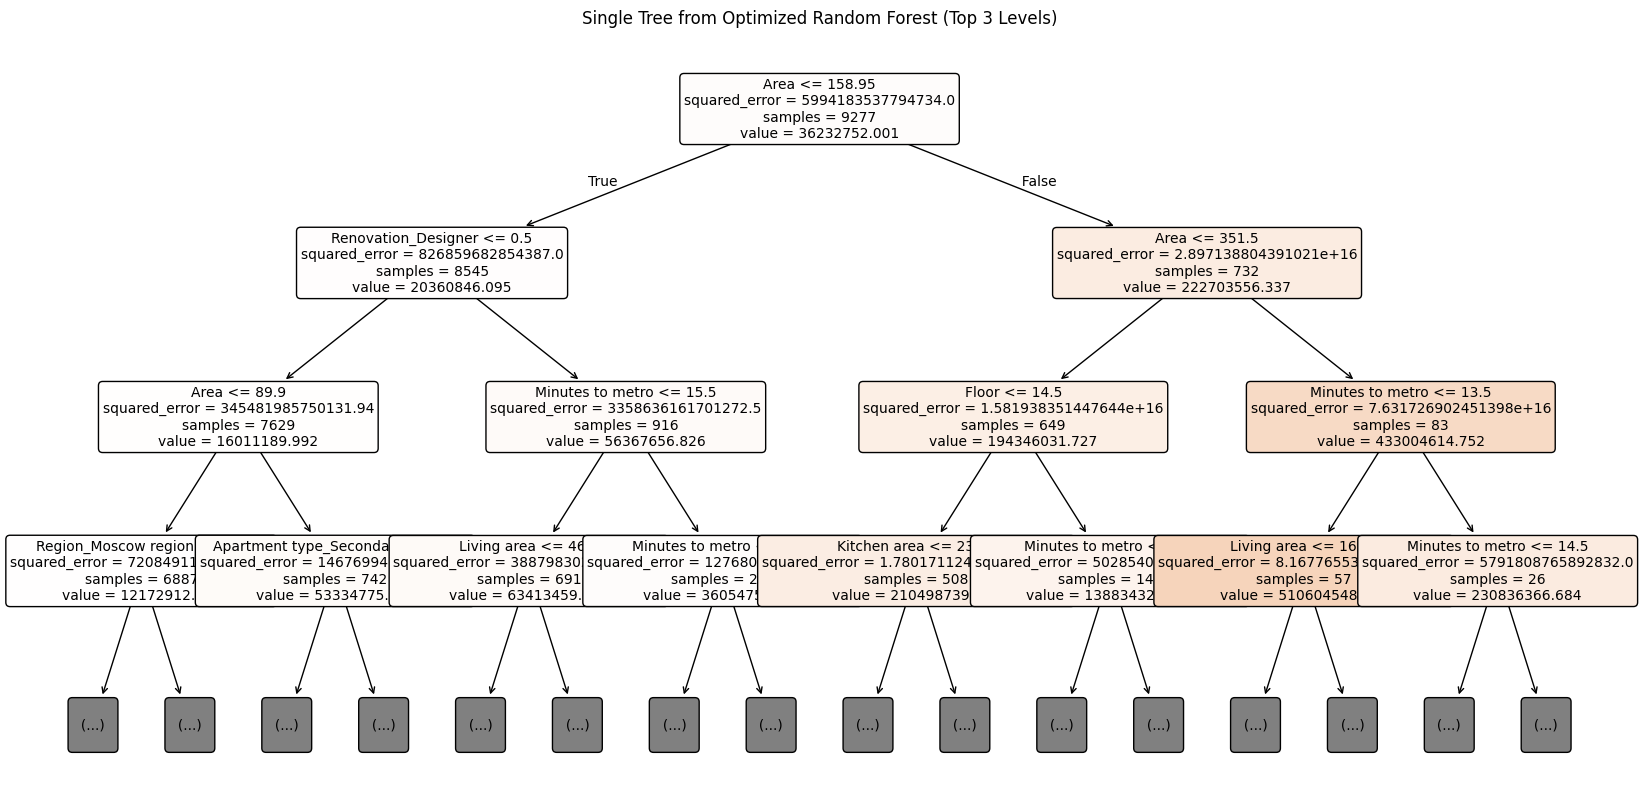

In [11]:
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

random_search_rf = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42),
                                      param_distributions=rf_param_dist,
                                      n_iter=10, # Number of parameter settings sampled
                                      cv=3,
                                      scoring='neg_mean_squared_error',
                                      n_jobs=-1,
                                      random_state=42)

random_search_rf.fit(X_train, y_train)
rf_optimized = random_search_rf.best_estimator_

# Predictions and metrics
rf_preds = rf_optimized.predict(X_test)
rf_r2 = r2_score(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print("Optimized Random Forest:")
print(f"Best Params: {random_search_rf.best_params_}")
print(f"R-squared:   {rf_r2:.4f}")
print(f"RMSE:        {rf_rmse:.2f}\n")

# Visualize a Single Tree from the Random Forest
# A Random Forest is an ensemble of many trees. You cannot plot the "entire forest"
# at once, but you can extract and look at an individual tree (e.g., the first one).
first_rf_tree = rf_optimized.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(first_rf_tree,
          feature_names=X_train.columns.tolist(),
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title("Single Tree from Optimized Random Forest (Top 3 Levels)")
plt.show()

# Step 4: Compare the Metrics

In [12]:
print("=== Model Comparison ===")
print(f"1. Initial Decision Tree -> R2: {dt_initial_r2:.4f} | RMSE: {dt_initial_rmse:.2f}")
print(f"2. Optimized Decision Tree -> R2: {dt_opt_r2:.4f} | RMSE: {dt_opt_rmse:.2f}")
print(f"3. Optimized Random Forest -> R2: {rf_r2:.4f} | RMSE: {rf_rmse:.2f}")

=== Model Comparison ===
1. Initial Decision Tree -> R2: 0.5763 | RMSE: 60404260.45
2. Optimized Decision Tree -> R2: 0.6135 | RMSE: 57694259.85
3. Optimized Random Forest -> R2: 0.6922 | RMSE: 51486117.13


# Step 5: Identify Most Important Features

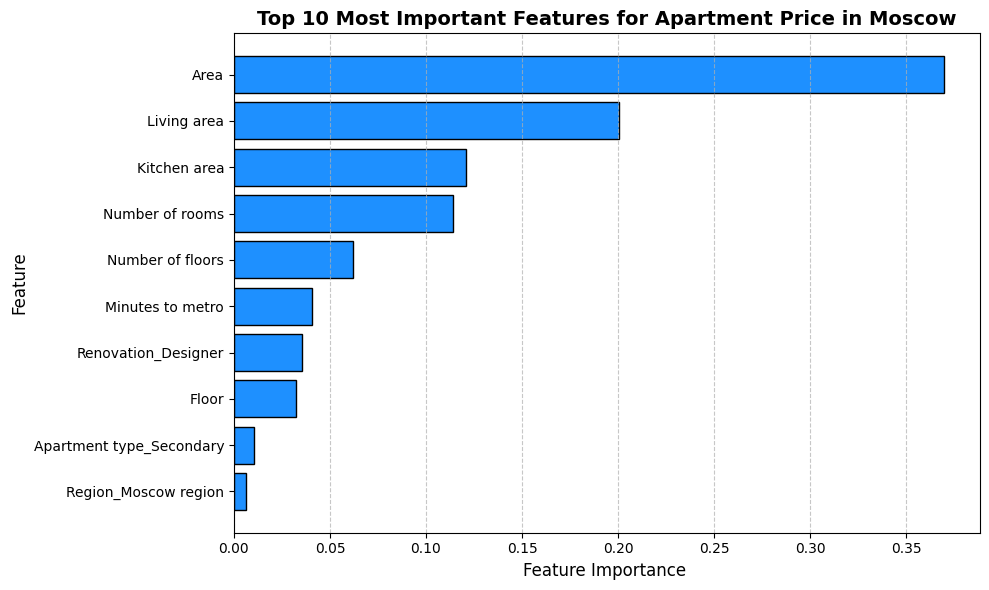

In [13]:
# Extract feature importances
importances = rf_optimized.feature_importances_
feature_names = X_train.columns

# Create a DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance in ascending order
importance_df = importance_df.sort_values(by='Importance', ascending=True)

# Select top 10 most important features
top_10 = importance_df.tail(10)

# Plot the horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_10['Feature'], top_10['Importance'], color='dodgerblue', edgecolor='black')

# Formatting the chart
plt.xlabel('Feature Importance ', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 10 Most Important Features for Apartment Price in Moscow', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()